In [1]:
# Minimal PyTorch + GPyTorch implementation of Logistic GP density regression
# with a mixture variational posterior over f_z at inducing points
# (learns mixture weights ω, means μ_k, and diagonal covariances Σ_k = diag(v_k)).

import math
import torch
import torch.nn as nn
import torch.optim as optim
import gpytorch
import numpy as np
import matplotlib.pyplot as plt
from torch.distributions import Normal
from dataclasses import dataclass
from scipy.stats import norm, t as student_t

torch.set_default_dtype(torch.float64)
torch.manual_seed(2)
np.random.seed(2)

# -----------------------------
# 1) Generate data and fit linear regression
# -----------------------------
def make_toy(n=700, seed=3):
    g = torch.Generator().manual_seed(seed)
    x = torch.rand(n, generator=g)
    y = x + x**2 + torch.randn(n, generator=g) * (0.2 * x)
    return x, y

device = torch.device("cpu")
n_train = 5000
n_test = 50000
x_all, y_all = make_toy(n=n_train + n_test, seed=3)
rand_indices = torch.randperm(x_all.size(0), generator=torch.Generator().manual_seed(2))
x, y = x_all[rand_indices[:n_train]], y_all[rand_indices[:n_train]]
x_test, y_test = x_all[rand_indices[n_train:]], y_all[rand_indices[n_train:]]
x = x.to(device)
y = y.to(device)

# Fit linear regression for both bases (no intercept)
x_np = x.cpu().numpy().reshape(-1, 1)
y_np = y.cpu().numpy()
slope = np.linalg.lstsq(x_np, y_np, rcond=None)[0][0]
y_pred = slope * x_np.flatten()
residuals = y_np - y_pred
sig_base = np.std(residuals, ddof=1)

b_base = slope
SIGMA_NORMAL = sig_base * 3

ORIGINAL_SIGMA_NORMAL = sig_base

# the moment matching t uses the same slope and the same residual std, but with heavier tails (df=3)
B_T = b_base
SCALE_T = SIGMA_NORMAL
DF = 3.0

print(f"Base model g_tilde (Normal): loc = {b_base:.3f}*x, scale = {SIGMA_NORMAL:.3f}")
print(f"Base model g (t-dist): loc = {B_T:.3f}*x, scale = {SCALE_T:.3f}, df = {DF}")

def normal_pdf(y, mu, sigma):
    # torch-normal PDF (kept for reference)
    return (1.0 / (math.sqrt(2.0 * math.pi) * sigma)) * torch.exp(-0.5 * ((y - mu) / sigma)**2)

def t_pdf(y, mu, sigma, df=3.0):
    """
    Student's t-distribution PDF using scipy.
    Returns PDF of t(loc=mu, scale=sigma, df=df) at y.
    """
    # Convert to numpy for scipy
    mu_np = mu.cpu().numpy() if torch.is_tensor(mu) else mu
    sigma_np = sigma.cpu().numpy() if torch.is_tensor(sigma) else sigma
    y_np = y.cpu().numpy()
    
    # Use scipy student_t
    pdf_np = student_t.pdf(y_np, df, loc=mu_np, scale=sigma_np)
    return torch.tensor(pdf_np, dtype=y.dtype, device=y.device)

def base_g_terms(y, x, b=None, sigma=None, df=DF):
    """
    Base model using Student's t-distribution: t(loc=b*x, scale=sigma, df=df).
    Returns g(y|x), g'(y|x), g''(y|x).
    Uses scipy.stats.student_t.
    """
    if b is None:
        b = B_T
    if sigma is None:
        sigma = SCALE_T
    
    # Convert to tensors to enable tensor*tensor operations
    b = torch.as_tensor(b, dtype=x.dtype, device=x.device)
    sigma = torch.as_tensor(sigma, dtype=x.dtype, device=x.device)
    
    mu = b * x
    
    # Convert to numpy for scipy
    mu_np = mu.cpu().numpy()
    sigma_np = sigma.cpu().numpy() if torch.is_tensor(sigma) else sigma
    y_np = y.cpu().numpy()
    
    # Use scipy.stats.student_t
    g_np = student_t.pdf(y_np, df, loc=mu_np, scale=sigma_np)
    g = torch.tensor(g_np, dtype=y.dtype, device=y.device)
    
    # Compute derivatives using manual formulas
    z = (y - mu) / sigma
    gy = -(df + 1) * z * g / (sigma * (df + z**2))
    gyy = g * (-(df + 1) / (sigma**2 * (df + z**2)) + (df + 1) * z**2 * (df + 3) / (sigma**2 * (df + z**2)**2))
    
    return g, gy, gyy

def to_z_from_y(y, x, b=None, sigma=None, df=DF):
    """
    Transform y to z using CDF of Student's t-distribution.
    z = CDF_t((y - mu) / sigma)
    Uses t(loc=b*x, scale=sigma, df=df).
    """
    if b is None:
        b = B_T
    if sigma is None:
        sigma = SCALE_T
    
    # Convert to tensors to enable tensor*tensor operations
    b = torch.as_tensor(b, dtype=x.dtype, device=x.device)
    sigma = torch.as_tensor(sigma, dtype=x.dtype, device=x.device)
        
    mu = b * x
    # Use scipy.stats.t with explicit loc and scale
    mu_np = mu.cpu().numpy()
    sigma_np = sigma.cpu().numpy()
    y_np = y.cpu().numpy()
    z_np = student_t.cdf(y_np, df, loc=mu_np, scale=sigma_np)
    z = torch.tensor(z_np, dtype=y.dtype, device=y.device)
    
    return z


# -----------------------------
# 2) Kernel (RBF with ARD) and derivative blocks
# -----------------------------
@dataclass
class KernelParams:
    log_sigma2: float = math.log(0.3323**2)  
    log_lx2: float    = math.log(0.1633**2) 
    log_lz2: float    = math.log(0.2312**2) 

    @property
    def sigma2(self): return math.exp(self.log_sigma2)
    @property
    def lx2(self):    return math.exp(self.log_lx2)
    @property
    def lz2(self):    return math.exp(self.log_lz2)

class RBF_SE_ARD(nn.Module):
    """
    Just wraps GPyTorch's RBFKernel+ScaleKernel to compute the base k((x,z),(x',z')).
    We still implement the derivative covariances in closed-form (simple and fast).
    """
    def __init__(self, kp: KernelParams):
        super().__init__()
        self.register_buffer("lx2", torch.tensor(kp.lx2)) # lx2 = 1/lengthscale_x^2
        self.register_buffer("lz2", torch.tensor(kp.lz2)) # lz2 = 1/lengthscale_z
        self.register_buffer("sigma2", torch.tensor(kp.sigma2))
        # A small GPyTorch kernel to show usage (we won't use autograd for derivatives here).
        self.base = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel(ard_num_dims=2, has_lengthscale=True)
        )
        # Fix the hyperparameters for presentation clarity:
        with torch.no_grad():
            # lengthscales per-dimension: [sqrt(lx2), sqrt(lz2)]
            self.base.base_kernel.lengthscale = torch.sqrt(torch.tensor([kp.lx2, kp.lz2]))[None, None, :]
            self.base.outputscale = torch.tensor(kp.sigma2) # initialized value of σ^2 for covariance function

    def cov(self, X, U):
        # X, U: (..., 2)
        return self.base(X, U).evaluate()

    def delta_01(self, V, U):
        # Cov(f, f'_z) = ∂/∂z' k
        # Using closed-form for RBF:
        # k = σ^2 exp(-(dx^2/lx2 + dz^2/lz2))
        # ∂k/∂z' = k * (2 (z - z') / lz2)
        x1 = V[:, 0:1]; z1 = V[:, 1:2]
        x2 = U[:, 0:1].T; z2 = U[:, 1:2].T
        dx2 = (x1 - x2)**2 / self.lx2
        dz  = (z1 - z2)
        dz2 = (dz**2) / self.lz2
        K = self.sigma2 * torch.exp(-(dx2 + dz2))
        return K * (2.0 * dz / self.lz2)

    def delta_11(self, V, U):
        # Cov(f'_z, f'_z) = ∂^2/(∂z ∂z') k
        x1 = V[:, 0:1]; z1 = V[:, 1:2]
        x2 = U[:, 0:1].T; z2 = U[:, 1:2].T
        dx2 = (x1 - x2)**2 / self.lx2
        dz  = (z1 - z2)
        dz2 = (dz**2) / self.lz2
        K = self.sigma2 * torch.exp(-(dx2 + dz2))
        result = (2.0/self.lz2) * K * (1.0 - 2.0 * (dz2))
        
        # Add small nugget to diagonal for numerical stability
        if V.shape[0] == U.shape[0] and torch.allclose(V, U):
            result += 1e-10 * torch.eye(V.shape[0], dtype=V.dtype, device=V.device)
            
        return result

    def delta_21(self, V, U):
        # Cov(f''_z, f'_z) = ∂^3/(∂z^2 ∂z') k
        x1 = V[:, 0:1]; z1 = V[:, 1:2]
        x2 = U[:, 0:1].T; z2 = U[:, 1:2].T
        dx2 = (x1 - x2)**2 / self.lx2
        dz  = (z1 - z2)
        dz2 = (dz**2) / self.lz2
        K = self.sigma2 * torch.exp(-(dx2 + dz2))
        return K * (8.0 * (dz**3) / (self.lz2**3) - 12.0 * dz / (self.lz2**2))
    

def chol_inv(K):
    """Improved Cholesky inversion with adaptive jitter"""
    # Add jitter to diagonal
    K_reg = K #+ current_jitter * torch.eye(K.size(-1), dtype=K.dtype, device=K.device)
    L = torch.linalg.cholesky(K_reg)
    I = torch.eye(K.size(-1), dtype=K.dtype, device=K.device)
    Kinv = torch.cholesky_solve(I, L)
    return Kinv, L
    

# 3) Variational mixture over f_z (diagonal Σ_k)
# -----------------------------
class LogisticGPMixtureDiag(nn.Module):
    """
    Variational family: q(f̃_z) = Σ_k ω_k N(μ_k, diag(v_k)), v_k = exp(2 s_k).
    Minimizes:  KL(q || GP prior on f'_z at inducing) + β * Hyvärinen score.
    """
    def __init__(self, x, y, C=2, m_induce=121, beta=1.0, seed=2, kp: KernelParams = KernelParams()):
        super().__init__()
        g = torch.Generator().manual_seed(seed)

        self.x = x.detach()
        self.y = y.detach()
        self.n = x.numel()
        self.C = C
        self.beta = beta
        self.kern = RBF_SE_ARD(kp)

        # Transform to z and build training inputs V = (x, z)
        z = to_z_from_y(self.y, self.x)

        # plt.hist(z.cpu().numpy(), bins=30, density=True)
        # plt.show()

        z = torch.clamp(z, 1e-5, 1-1e-5)
        self.V = torch.stack([self.x, z], dim=1)  # (n, 2)

        # Simple grid inducing points in (x,z) - avoid boundary issues
        s = int(math.sqrt(m_induce))
        # Now inducing points are on a grid in (x,z) space
        gx = torch.linspace(self.x.min(), self.x.max(), s)
        gz = torch.linspace(1e-3, 1-1e-3, s)  # Better spacing to avoid numerical issues
        Xg, Zg = torch.meshgrid(gx, gz, indexing="ij")
        
        self.Vu = torch.stack([Xg.reshape(-1), Zg.reshape(-1)], dim=1)  # (m, 2), m = s^2
        self.m = self.Vu.size(0)

        # Base model terms
        self.g, self.gy, self.gyy = base_g_terms(self.y, self.x)

        # Kernel blocks
        self.K11uu = self.kern.delta_11(self.Vu, self.Vu)        # (m, m)
        self.K11uu_inv, self.K11uu_chol = chol_inv(self.K11uu)  # Increased jitter
        self.A = self.kern.delta_11(self.V, self.Vu) @ self.K11uu_inv   # (n, m)
        # self.A = torch.linalg.solve(self.K11uu.T, self.kern.delta_11(self.V, self.Vu).T).T
        self.B = self.kern.delta_21(self.V, self.Vu) @ self.K11uu_inv   # (n, m)
        # self.B = torch.linalg.solve(self.K11uu.T, self.kern.delta_21(self.V, self.Vu).T).T

        self.A2 = self.A**2
        self.A2T_g2_over_n = self.A2.T @ ((self.g**2) / self.n)  # (m,)

        # Variational parameters
        self.logits = nn.Parameter(torch.randn(C))                       # mixture weights (softmax)
        self.mus    = nn.Parameter(torch.randn(C, self.m))               # means
        init_log_std = math.log(0.35) # log 0.35 math.exp(-3)
        self.s_params = nn.Parameter(torch.full((C, self.m), init_log_std))  # log std per dim

        # Warm-start μ (single-component quadratic surrogate)
        self.warm_start_mu()

    def warm_start_mu(self):
        c = self.gy / self.g
        lin = (2.0 * self.gy + 2.0 * c * self.g)              # (n,)
        W = (self.g ** 2)                                     # (n,)
        AtW = self.A.T * (W / self.n)                         # (m, n)
        H = self.K11uu_inv + 2.0 * self.beta * (AtW @ self.A) # (m, m)
        b = self.beta * (self.A.T @ (lin / self.n))           # (m,)

        # Use stable Cholesky for warm start
        try:
            L = torch.linalg.cholesky(H) #+ 1e-6 * torch.eye(self.m, dtype=H.dtype, device=H.device)
            mu_ls = -torch.cholesky_solve(b.unsqueeze(-1), L).squeeze(-1)
        except:
            # Fallback to direct solve if Cholesky fails
            mu_ls = -torch.linalg.solve(H , b) # + 1e-6 * torch.eye(self.m)

        with torch.no_grad():
            for k in range(self.C):
                self.mus[k].copy_(mu_ls / self.C + 0.03 * torch.randn_like(mu_ls))

    def forward_objective(self):
        """
        Compute the scalar objective and autograd will populate grads:
        F = KL(q || GP prior) + β * EH
        """
        # print(self.K11uu_inv)
        logits = self.logits
        w = torch.softmax(logits, dim=0)                           # (C,)
        v_list = torch.exp(2.0 * self.s_params)                    # (C, m)
        aMu = (self.A @ self.mus.T).T                              # (C, n)
        mu_bar = torch.sum(w[:, None] * self.mus, dim=0)           # (m,)
        Ez = self.A @ mu_bar                                       # (n,)
        Efzz = self.B @ mu_bar                                     # (n,)

        g, gy, gyy = self.g, self.gy, self.gyy
        c = gy / g
        # const = 2.0 * ((g * gyy - gy**2) / (g**2)) + c**2          # (n,)
        # lin_coeff = 2.0 * gy + 2.0 * c * g                         # (n,)

        const     = (gyy / g) - 0.5 * (c**2)     # constant part
        lin_coeff = 2.0 * gy                      # linear-in-E[f_z]

        v_list = torch.exp(2.0 * self.s_params)                    # (C, m)
        row_var = (self.A2 @ v_list.T).T                           # (C, n)  each row k: A^2 v_k

        Efz2 = torch.sum(w[:, None] * (row_var + aMu**2), dim=0)   # (n,)
        # EH = torch.mean(const + lin_coeff * Ez + (g**2) * Efz2 + 2.0 * (g**2) * Efzz)
        EH = torch.mean(const + lin_coeff * Ez + 0.5 * (g**2) * Efz2 + 1.0 * (g**2) * Efzz)

        # KL per component vs N(0, K11uu)
        Kinv = self.K11uu_inv
        
        # More stable log determinant computation
        if self.K11uu_chol is not None:
            logdetK = 2.0 * torch.log(torch.diag(self.K11uu_chol)).sum()
        else:
            sign, logdetK = torch.slogdet(self.K11uu)

        # sign, logdetK = torch.slogdet(self.K11uu)
            
        diag_Kinv = torch.diag(Kinv)
        KL_k = []
        for k in range(self.C):
            mu_k = self.mus[k]                      # (m,)
            v_k  = v_list[k]                        # (m,)
            quad = mu_k @ (Kinv @ mu_k)            # scalar # torch.solve(K, mu_k)
            # quad = mu_k @ torch.linalg.solve(self.K11uu, mu_k)
            tr   = torch.dot(diag_Kinv, v_k)       # scalar
            logdetSigma = 2.0 * torch.sum(self.s_params[k]) #torch.sum(torch.log(v_k))
            KL_k.append(0.5 * (tr + quad - self.m + logdetK - logdetSigma))
        KL_k = torch.stack(KL_k)                    # (C,)
        KL = torch.sum(w * KL_k)

        F = KL + self.beta * EH
        # print(KL, EH)
        return F, {"KL": KL.detach(), "EH": EH.detach(), "w": w.detach()}

    @torch.no_grad()
    def predict_density(self, x_star: float, y_min=-0.2, y_max=2.5, M=700, df=DF):
        y_grid = torch.linspace(y_min, y_max, M, dtype=self.x.dtype)
        z_grid = to_z_from_y(y_grid, torch.full_like(y_grid, x_star), b=B_T, sigma=SCALE_T, df=df)
        z_grid = torch.clamp(z_grid, 1e-6, 1-1e-6)

        Vq = torch.stack([torch.full_like(z_grid, x_star), z_grid], dim=1)  # (M, 2)
        K01 = self.kern.delta_01(Vq, self.Vu)

        w = torch.softmax(self.logits, dim=0)
        m_tilde = torch.sum(w[:, None] * self.mus, dim=0)
        alpha = self.K11uu_inv @ m_tilde
        f_vals = K01 @ alpha
        g_vals = t_pdf(y_grid, B_T * x_star, SCALE_T, df)


        # Improved normalization - more stable trapezoid rule
        idx = torch.argsort(z_grid)
        z_sorted = z_grid[idx]
        f_sorted = f_vals[idx]
        
        dz = z_sorted[1:] - z_sorted[:-1]
        wts = torch.zeros_like(z_sorted)
        wts[0] = dz[0] / 2.0
        wts[-1] = dz[-1] / 2.0
        wts[1:-1] = (dz[:-1] + dz[1:]) / 2.0
        
        exp_f = torch.exp(torch.clamp(f_sorted, -50, 50))
        denom = torch.sum(exp_f * wts) + 1e-12

        h_hat = g_vals * torch.exp(torch.clamp(f_vals, -50, 50)) / denom
        return y_grid.cpu().numpy(), g_vals.cpu().numpy(), h_hat.cpu().numpy(), exp_f.cpu().numpy(), z_grid.cpu().numpy()

    @torch.no_grad()
    def predict_f_and_derivs(self, x_star: float, y_min=-0.2, y_max=2.5, M=700, df=DF):
        y_grid = torch.linspace(y_min, y_max, M, dtype=self.x.dtype)
        z_grid = to_z_from_y(y_grid, torch.full_like(y_grid, x_star), b=B_T, sigma=SCALE_T, df=df)
        # z_grid = torch.clamp(z_grid, 1e-6, 1-1e-6)
        Vq = torch.stack([torch.full_like(z_grid, x_star), z_grid], dim=1)

        K01 = self.kern.delta_01(Vq, self.Vu)
        K11 = self.kern.delta_11(Vq, self.Vu)
        K21 = self.kern.delta_21(Vq, self.Vu)

        w = torch.softmax(self.logits, dim=0)
        m_tilde = torch.sum(w[:, None] * self.mus, dim=0)
        alpha = self.K11uu_inv @ m_tilde

        f_vals   = K01 @ alpha
        fz_vals  = K11 @ alpha
        fzz_vals = K21 @ alpha
        
        return z_grid.cpu().numpy(), f_vals.cpu().numpy(), fz_vals.cpu().numpy(), fzz_vals.cpu().numpy()


Base model g_tilde (Normal): loc = 1.745*x, scale = 0.464
Base model g (t-dist): loc = 1.745*x, scale = 0.464, df = 3.0


Iteration      0 | LR: 5.00e-01 | KL: 12934.486144 | β×EH: 3688.778693 | F: 16623.264837
Iteration  10000 | LR: 5.00e-01 | KL: 48152.682103 | β×EH: -248064.399952 | F: -199911.717849
Iteration  20000 | LR: 5.00e-01 | KL: 54712.980209 | β×EH: -260910.460360 | F: -206197.480151
Iteration  30000 | LR: 5.00e-01 | KL: 56496.385267 | β×EH: -264072.271914 | F: -207575.886646
Iteration  40000 | LR: 5.00e-01 | KL: 57299.667480 | β×EH: -265279.625313 | F: -207979.957833
Iteration  50000 | LR: 5.00e-01 | KL: 125526.787583 | β×EH: -265834.142439 | F: -140307.354856
Iteration  60000 | LR: 5.00e-01 | KL: 57732.746767 | β×EH: -266170.074568 | F: -208437.327801
Iteration  70000 | LR: 5.00e-01 | KL: 57856.211975 | β×EH: -266360.626485 | F: -208504.414510
Iteration  80000 | LR: 5.00e-01 | KL: 57939.477991 | β×EH: -266483.074423 | F: -208543.596432
Iteration  90000 | LR: 5.00e-01 | KL: 57998.256414 | β×EH: -266565.483777 | F: -208567.227363
Iteration 100000 | LR: 5.00e-01 | KL: 58041.288535 | β×EH: -2666

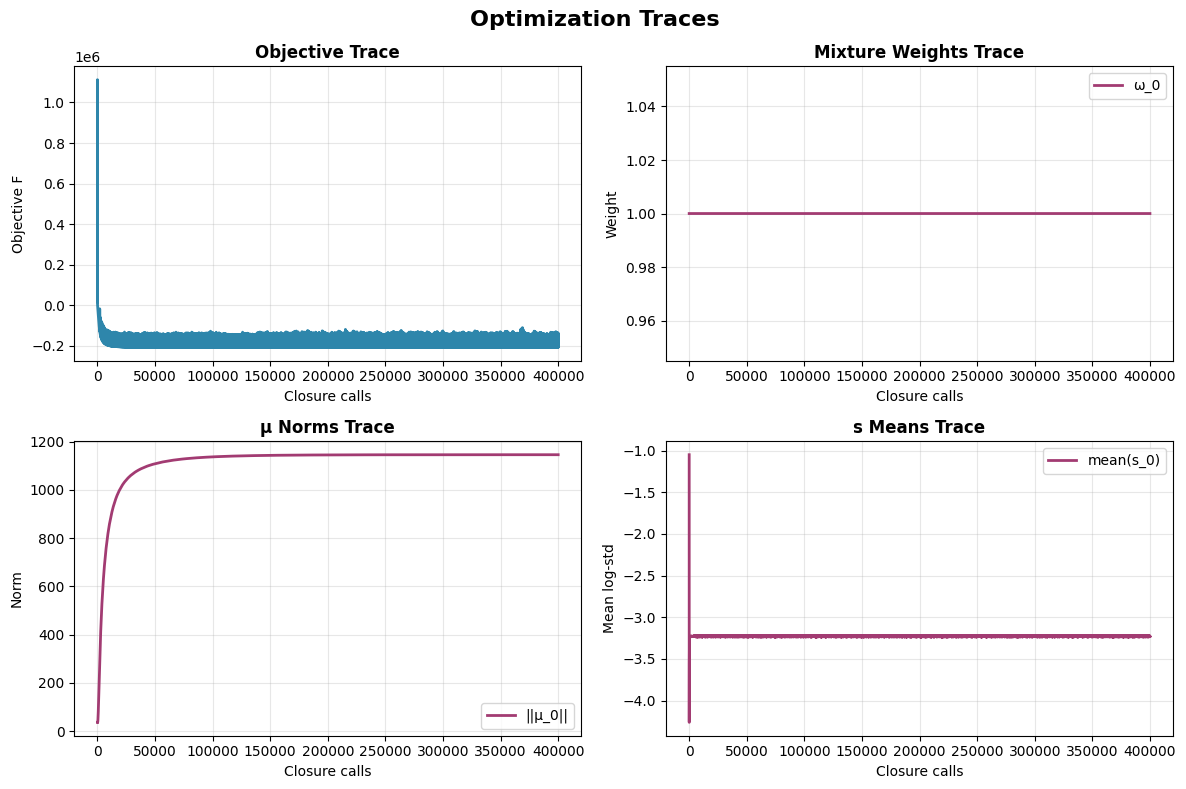

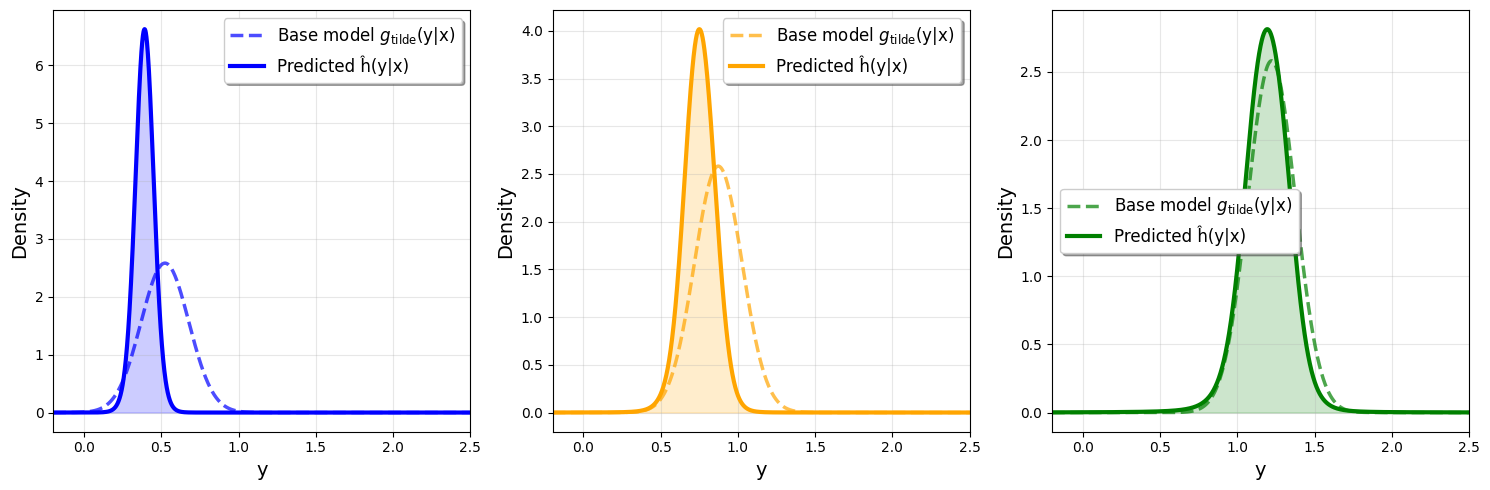

In [2]:
# 4) Train with Adam optimizer and plot
# -----------------------------
if __name__ == "__main__":
    torch.manual_seed(2)
    np.random.seed(2)

    model = LogisticGPMixtureDiag(x, y, C=1, m_induce=150, beta=680.09, seed=2).to(device) # 150 633 680.09
    
    trace = {"F": [], "KL": [], "beta_EH": [], "w": [], "mu_norm": [], "s_mean": [], 
             "mu_samples": [], "s_samples": []}  # Added raw parameter samples
    # Adam optimizer with learning rate decay and minimum LR threshold
    initial_lr = 0.5
    optimizer = optim.Adam(model.parameters(),lr=initial_lr)
    
    max_grad_norm = 5.0  # Stronger gradient clipping to prevent spikes
    
    # Iterate averaging: average parameters over last 5000 steps
    num_iterations = 400000
    averaging_window = 5000
    start_averaging = num_iterations - averaging_window
    
    # Storage for averaged parameters
    averaged_params = None
    
    def closure():
        optimizer.zero_grad()
        F, info = model.forward_objective()

        # --- log parameter traces ---
        with torch.no_grad():
            w = torch.softmax(model.logits, dim=0).detach().cpu()
            mu_norm = torch.linalg.norm(model.mus, dim=1).detach().cpu()   # one norm per component
            s_mean = torch.mean(model.s_params, dim=1).detach().cpu()      # mean log-std per component
            # Sample a few individual parameter values (e.g., first 3 dimensions of first component)
            mu_samples = model.mus[0, :3].detach().cpu()  # First 3 mu parameters of component 0
            s_samples = model.s_params[0, :3].detach().cpu()  # First 3 s parameters of component 0
            
            trace["F"].append(float(F.detach()))
            trace["KL"].append(float(info["KL"]))
            trace["beta_EH"].append(float(model.beta * info["EH"]))  # Store weighted term
            trace["w"].append(w.numpy().copy())
            trace["mu_norm"].append(mu_norm.numpy().copy())
            trace["s_mean"].append(s_mean.numpy().copy())
            trace["mu_samples"].append(mu_samples.numpy().copy())
            trace["s_samples"].append(s_samples.numpy().copy())

        # ----------------------------

        F.backward()
        return F

    # Training loop
    print_interval = 10000  # Print progress every 10000 iterations
    
    for iteration in range(num_iterations):
        loss = closure()
        
        # Clip gradients to prevent large spikes (optional)
        #torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        
        optimizer.step()
        # scheduler.step()  # Update learning rate (commented out for iterate averaging)
        
        # Iterate averaging: accumulate parameter averages over last 5000 steps
        if iteration >= start_averaging:
            with torch.no_grad():
                if averaged_params is None:
                    # Initialize averaged parameters
                    averaged_params = {name: param.clone() for name, param in model.named_parameters()}
                    num_averaged = 1
                else:
                    # Update running average: avg = (avg * n + new) / (n + 1)
                    num_averaged = iteration - start_averaging + 1
                    for name, param in model.named_parameters():
                        averaged_params[name] = (averaged_params[name] * (num_averaged - 1) + param) / num_averaged
        
        # Print progress periodically
        if iteration % print_interval == 0:
            current_lr = optimizer.param_groups[0]['lr']
            averaging_status = f" | Averaging: {iteration - start_averaging + 1}/{averaging_window}" if iteration >= start_averaging else ""
            print(f"Iteration {iteration:6d} | LR: {current_lr:.2e} | KL: {trace['KL'][-1]:10.6f} | β×EH: {trace['beta_EH'][-1]:10.6f} | F: {float(loss.detach()):10.6f}{averaging_status}")
    
    # Apply averaged parameters to model
    if averaged_params is not None:
        with torch.no_grad():
            for name, param in model.named_parameters():
                param.copy_(averaged_params[name])
        print(f"\nApplied iterate averaging over last {averaging_window} steps")

    steps = range(len(trace["F"]))

    # ============================
    # Group Figure 1: Optimization Traces (2×2 layout)
    # ============================
    fig1, axes1 = plt.subplots(2, 2, figsize=(12, 8))
    
    # Objective trace
    axes1[0,0].plot(steps, trace["F"], color='#2E86AB', linewidth=2)
    axes1[0,0].set_xlabel("Closure calls")
    axes1[0,0].set_ylabel("Objective F")
    axes1[0,0].set_title("Objective Trace", fontweight='bold')
    axes1[0,0].grid(True, alpha=0.3)
    
    # Mixture weights trace
    W = np.stack(trace["w"])  # shape [T, C]
    colors_weights = ['#A23B72', '#F18F01', '#6A0572', '#AB83A1', '#F08A5D', '#B83B5E', '#6A0572', '#C0E218', '#3F88C5', '#F2545B']
    for k in range(W.shape[1]):
        axes1[0,1].plot(steps, W[:, k], label=f"ω_{k}", color=colors_weights[k], linewidth=2)
    axes1[0,1].set_xlabel("Closure calls")
    axes1[0,1].set_ylabel("Weight")
    axes1[0,1].set_title("Mixture Weights Trace", fontweight='bold')
    axes1[0,1].legend()
    axes1[0,1].grid(True, alpha=0.3)
    
    # μ norms trace
    MU = np.stack(trace["mu_norm"])  # [T, C]
    for k in range(MU.shape[1]):
        axes1[1,0].plot(steps, MU[:, k], label=f"||μ_{k}||", color=colors_weights[k], linewidth=2)
    axes1[1,0].set_xlabel("Closure calls")
    axes1[1,0].set_ylabel("Norm")
    axes1[1,0].set_title("μ Norms Trace", fontweight='bold')
    axes1[1,0].legend()
    axes1[1,0].grid(True, alpha=0.3)
    
    # s means trace
    S = np.stack(trace["s_mean"])  # [T, C]
    for k in range(S.shape[1]):
        axes1[1,1].plot(steps, S[:, k], label=f"mean(s_{k})", color=colors_weights[k], linewidth=2)
    axes1[1,1].set_xlabel("Closure calls")
    axes1[1,1].set_ylabel("Mean log-std")
    axes1[1,1].set_title("s Means Trace", fontweight='bold')
    axes1[1,1].legend()
    axes1[1,1].grid(True, alpha=0.3)
    
    plt.suptitle('Optimization Traces', fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.savefig("optimization_traces.pdf", dpi=300, bbox_inches="tight")
    plt.show()
    
    # ============================
    # Group Figure 2: Density Comparisons (1×3 layout)
    # ============================
    fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5))
    x_values = [0.3, 0.5, 0.7]
    colors_density = ['blue', 'orange', 'green']
    
    for i, (ax, x_star) in enumerate(zip(axes2, x_values)):
        y_grid, g_vals, h_hat, _, _ = model.predict_density(x_star, y_min=-0.2, y_max=2.5, M=2000)
        
        # Compute g_tilde (Normal base) using ORIGINAL_SIGMA_NORMAL (not scaled by 3)
        g_tilde_vals = norm.pdf(y_grid, loc=b_base * x_star, scale=ORIGINAL_SIGMA_NORMAL)
        
        # Plot with enhanced styling
        ax.plot(y_grid, g_tilde_vals, '--', color=colors_density[i], linewidth=2.5, alpha=0.7, label='Base model $g_{\\mathrm{tilde}}$(y|x)')
        ax.plot(y_grid, h_hat, '-', color=colors_density[i], linewidth=3, label='Predicted ĥ(y|x)')
        
        # Styling
        ax.set_xlabel('y', fontsize=14)
        ax.set_ylabel('Density', fontsize=14)
        ax.legend(fontsize=12, frameon=True, fancybox=True, shadow=True)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(y_grid.min(), y_grid.max())
        
        # Add subtle background fill under the predicted curve
        ax.fill_between(y_grid, 0, h_hat, alpha=0.2, color=colors_density[i])
    
    plt.tight_layout()

    plt.savefig("density_comparisons.pdf", dpi=300, bbox_inches="tight")
    plt.show()


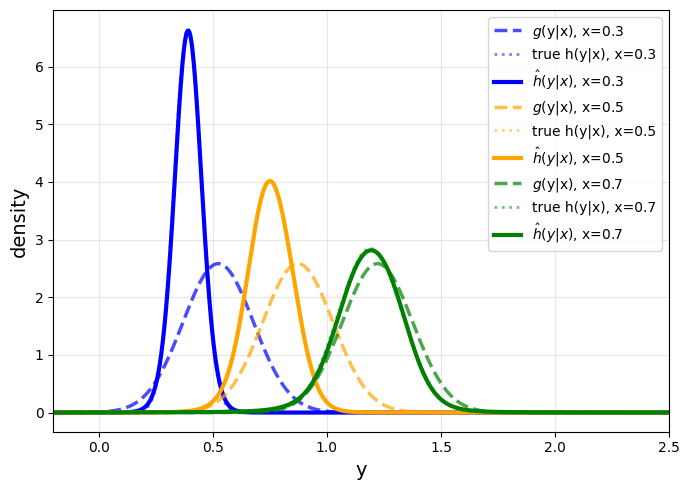

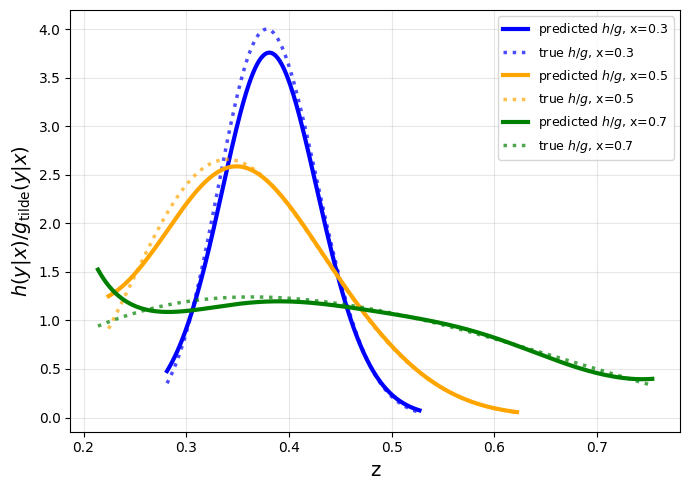

/var/folders/5q/r8dt0jb906xbzf494xwk97fw0000gn/T/ipykernel_33272/2147592322.py:238: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  h_hat_norm = hhat / (np.trapz(hhat, dx=dy))
/var/folders/5q/r8dt0jb906xbzf494xwk97fw0000gn/T/ipykernel_33272/2147592322.py:242: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  mean_y = np.trapz(yg * h_hat_norm, dx=dy)


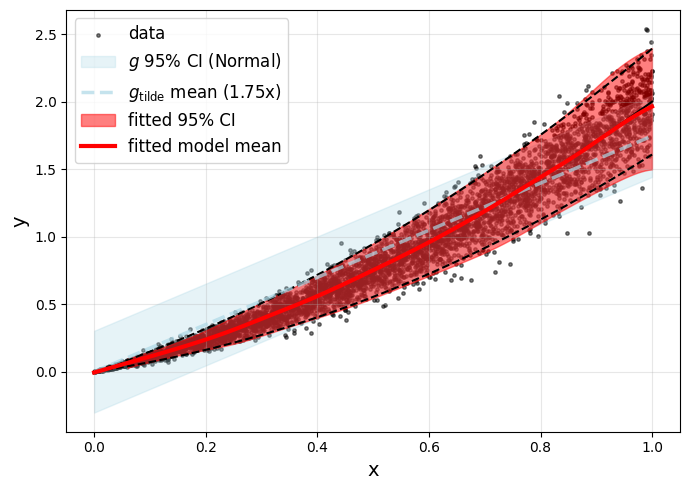


All panels saved separately:
  - Figure1_PanelA_densities.pdf
  - Figure1_PanelB_density_ratio.pdf
  - Figure1_PanelC_true_regression.pdf
  - Figure1_PanelD_f_z_derivative.pdf
  - Figure1_PanelE_f_zz_derivative.pdf


In [3]:
# ============================
# Full Figure 1 with derivative comparisons - Each Panel Saved Separately
# ============================

x_vals   = [0.3, 0.5, 0.7]
colors   = ['blue', 'orange', 'green']
y_min, y_max, M = -0.2, 2.5, 2000  # Extended range to capture full distribution tails


# Function to compute z-range where true density is high for a given x_star
def compute_high_density_z_range(x_star, base_density_threshold=0.001, df=3.0):
    """
    Find z-range where true density h_true(y|x) is above threshold.
    Returns (z_min, z_max) corresponding to high-density y region.
    """
    # True density is N(x + x^2, 0.2*x)
    mu_true = x_star + x_star**2
    sigma_true = 0.2 * x_star
    
    # Use quantiles: focus on central 99.5% of true distribution
    y_lower = norm.ppf(0.0025, loc=mu_true, scale=sigma_true)
    y_upper = norm.ppf(0.9975, loc=mu_true, scale=sigma_true)
    
    # Convert y bounds to z bounds using base model CDF (t-distribution)
    z_lower = student_t.cdf(y_lower, df, loc=B_T * x_star, scale=SCALE_T)
    z_upper = student_t.cdf(y_upper, df, loc=B_T * x_star, scale=SCALE_T)
    
    # Clip to valid range
    z_lower = max(0.01, z_lower)
    z_upper = min(0.99, z_upper)
    
    return z_lower, z_upper

def true_h_np(y_np, x_star):
    # Paper's "gold" toy density: N(mean = x + x^2, sd = 0.2 x)
    mu = x_star + x_star**2
    sd = 0.2 * x_star
    return (1.0 / (np.sqrt(2*np.pi)*sd)) * np.exp(-0.5 * ((y_np - mu)/sd)**2)


def f_val_visual(x, z, df=DF):
    # Convert z back to y using t-distribution PPF
    y = student_t.ppf(z, df, loc=B_T * x, scale=SCALE_T)
    # True density is still Normal (this is the target density)
    log_true = norm.logpdf(y, loc=x + x**2, scale=0.2 * x)
    # Base model is now t-distribution
    log_base = student_t.logpdf(y, df, loc=B_T * x, scale=SCALE_T)
    return log_true - log_base

# First and second derivatives (true minus base), closed-form with t-distribution

def f_z_visual(x, z, df=DF):
    # Convert z to y using t-distribution
    y = student_t.ppf(z, df, loc=B_T * x, scale=SCALE_T)
    
    # For dy/dz, need standard t-distribution PDF at standardized quantile
    # Compute standardized value
    standardized = (y - B_T * x) / SCALE_T
    # Standard t-distribution PDF
    t_pdf_val = student_t.pdf(standardized, df, loc=0, scale=1)
    
    # dy/dz = sigma / t_pdf(standardized)
    y_z = SCALE_T / t_pdf_val
    
    # f_y = d/dy[log(h_true) - log(g_base)]
    # For true density: h_true is N(x + x^2, 0.2*x)
    mu_true = x + x**2
    sigma_true = 0.2 * x
    h_y_over_h_true = -(y - mu_true) / (sigma_true**2)
    
    # For base t-distribution: g_base is t(B_T*x, SCALE_T, df)
    # d/dy[log g] = -(df+1)*standardized / (scale * (df + standardized²))
    g_y_over_g_base = -(df + 1.0) * standardized / (SCALE_T * (df + standardized**2))
    
    f_y = h_y_over_h_true - g_y_over_g_base
    
    return f_y * y_z


def f_zz_visual(x, z, df=DF):
    # Convert z to y using t-distribution
    y = student_t.ppf(z, df, loc=B_T * x, scale=SCALE_T)
    
    # For dy/dz, need standard t-distribution PDF at standardized quantile
    # Compute standardized value
    standardized = (y - B_T * x) / SCALE_T
    # Standard t-distribution PDF
    t_pdf_val = student_t.pdf(standardized, df, loc=0, scale=1)
    
    # First derivatives
    y_z = SCALE_T / t_pdf_val
    
    # For dy_zz, we need d/dz[y_z] = d/dz[SCALE_T / t_pdf(standardized)]
    dt_dz = 1.0 / t_pdf_val
    dt_pdf_dt = t_pdf_val * (-(df + 1.0) * standardized / (df + standardized**2))
    y_zz = -SCALE_T * dt_pdf_dt * dt_dz / (t_pdf_val**2)
    
    # Second derivative of f in y-space
    mu_true = x + x**2
    sigma_true = 0.2 * x
    h_yy_over_h_true = ((y - mu_true)**2 / (sigma_true**4)) - (1.0 / (sigma_true**2))
    
    # For base t-distribution with fixed parameters
    term1 = (df + standardized**2)
    g_yy_over_g_base = -(df + 1.0) / (SCALE_T**2) * ((df - standardized**2) / (term1**2))
    
    f_yy = h_yy_over_h_true - g_yy_over_g_base
    
    # First derivative in y-space
    h_y_over_h_true = -(y - mu_true) / (sigma_true**2)
    g_y_over_g_base = -(df + 1.0) * standardized / (SCALE_T * term1)
    f_y = h_y_over_h_true - g_y_over_g_base
    
    # Chain rule: f_zz = f_yy * (y_z)^2 + f_y * y_zz
    return f_yy * (y_z**2) + f_y * y_zz


def estimate_mean_quantiles(yg,hhat,level=0.95):
    dy = np.diff(yg)
    w = np.empty_like(hhat)
    w[0] = dy[0] / 2.0
    w[-1] = dy[-1] / 2.0
    w[1:-1] = (dy[:-1] + dy[1:]) / 2.0
    p = hhat * w
    p /= p.sum()
    mean = np.dot(yg, p)
    cdf = np.cumsum(p)
    lower_quantile = np.interp((1-level)/2, cdf, yg)
    upper_quantile = np.interp(1-(1-level)/2, cdf, yg)
    return mean, lower_quantile, upper_quantile
    

# ==========================================
# Panel A: g_tilde (dashed), true h (dotted), estimated ĥ (solid)
# ==========================================
fig_a, ax_a = plt.subplots(1, 1, figsize=(7, 5))
for x_star, col in zip(x_vals, colors):
    yg, gg, hhat, _, _ = model.predict_density(x_star, y_min=y_min, y_max=y_max, M=M)
    _,f,_,_ = model.predict_f_and_derivs(x_star, y_min=y_min, y_max=y_max, M=M)
    h_true = true_h_np(yg, x_star)
    
    # g_tilde (Normal base) - dashed, colored - using ORIGINAL_SIGMA_NORMAL (not scaled by 3)
    g_tilde = norm.pdf(yg, loc=b_base * x_star, scale=ORIGINAL_SIGMA_NORMAL)
    ax_a.plot(yg, g_tilde, '--', color=col, lw=2.5, alpha=0.7, label=f"$g$(y|x), x={x_star}")
    # true h (paper) - dotted
    ax_a.plot(yg, h_true, ':', color=col, lw=2, alpha=0.5, label=f"true h(y|x), x={x_star}")
    # estimated h - solid
    ax_a.plot(yg, hhat, '-', color=col, lw=3, label=f"$\\hat h(y|x)$, x={x_star}")
    # ax_a.plot(yg, gg*np.exp(f)/np.trapz(gg*np.exp(f),dx=yg[1]-yg[0]), '-', color=col, lw=3, label=f"$\\hat h(y|x)$, x={x_star}, unnormalized")

ax_a.set_xlabel("y", fontsize=14)
ax_a.set_ylabel("density", fontsize=14)
ax_a.legend()
ax_a.grid(True, alpha=0.3)
ax_a.set_xlim(yg.min(), yg.max())
plt.tight_layout()
plt.savefig("Figure1_PanelA_densities.pdf", dpi=220, bbox_inches="tight")
plt.show()

# ==========================================
# Panel B: exp(f) where f = log(h/g_tilde) - density ratio relative to Normal base
# ==========================================
fig_b, ax_b = plt.subplots(1, 1, figsize=(7, 5))
for x_star, col in zip(x_vals, colors):
    zq, f_model, fz_model, fzz_model = model.predict_f_and_derivs(x_star, y_min=y_min, y_max=y_max, M=M)
    
    # Compute z-range where true density is high for this x_star
    z_min_dense, z_max_dense = compute_high_density_z_range(x_star)
    mask = (zq > z_min_dense) & (zq < z_max_dense)
    z_plot = zq[mask]
    
    # Convert z to y for computing g and g_tilde
    y_plot = student_t.ppf(z_plot, DF, loc=B_T * x_star, scale=SCALE_T)
    
    # Compute log(g/g_tilde) where g is t-dist base and g_tilde is Normal base
    # g: t-distribution with location=B_T*x, scale=SCALE_T, df=DF
    # g_tilde: Normal with location=b_base*x, scale=ORIGINAL_SIGMA_NORMAL (not scaled by 3)
    log_g = student_t.logpdf(y_plot, DF, loc=B_T * x_star, scale=SCALE_T)
    log_g_tilde = norm.logpdf(y_plot, loc=b_base * x_star, scale=ORIGINAL_SIGMA_NORMAL)
    log_g_over_g_tilde = log_g - log_g_tilde
    
    # Predicted: log(h/g_tilde) = log(h/g) + log(g/g_tilde) = f_model + log(g/g_tilde)
    pred_log_f_over_gtilde = f_model[mask] + log_g_over_g_tilde
    
    # True: log(h_true/g_tilde)
    log_h_true = norm.logpdf(y_plot, loc=x_star + x_star**2, scale=0.2 * x_star)
    true_log_f_over_gtilde = log_h_true - log_g_tilde
    
    # Apply shift to remove constant offset (crucial before taking exp)
    shift = np.mean(true_log_f_over_gtilde - pred_log_f_over_gtilde)
    pred_log_f_shifted = pred_log_f_over_gtilde + shift
    true_log_f_shifted = true_log_f_over_gtilde  # or equivalently: pred_log_f_shifted + (true - pred) with mean 0
    
    # Now take exp to get density ratios with consistent scaling
    pred_ratio = np.exp(pred_log_f_shifted)
    true_ratio = np.exp(true_log_f_shifted)
    
    ax_b.plot(z_plot, pred_ratio, '-', color=col, lw=3, label=f"predicted $h/g$, x={x_star}")
    ax_b.plot(z_plot, true_ratio, ':', color=col, lw=2.5, alpha=0.7, label=f"true $h/g$, x={x_star}")

ax_b.set_xlabel("z", fontsize=14)
ax_b.set_ylabel(r"$h(y|x) / g_{\mathrm{tilde}}(y|x)$", fontsize=14)
ax_b.legend(fontsize=9)
ax_b.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("Figure1_PanelB_density_ratio.pdf", dpi=220, bbox_inches="tight")
plt.show()


# ==========================================
# Panel C: fitted model prediction vs base model
# ==========================================
fig_c, ax_c = plt.subplots(1, 1, figsize=(7, 5))
x_line = np.linspace(float(x.min()), float(x.max()), 500)

# Base model distribution (using ORIGINAL_SIGMA_NORMAL, not scaled by 3)
mu_base = b_base * x_line

# Get fitted model predictions (mean and credible intervals from updated model)
# Using analytical mean and quantile-based credible intervals for accuracy
fitted_predictions = []
fitted_lower = []
fitted_upper = []

for x_star in x_line:
    # Get the density prediction once (more efficient and accurate)
    yg, gg, hhat, _, _ = model.predict_density(x_star, y_min=y_min, y_max=y_max, M=M)

    # # alternative approach: get f and compute mean and quantiles from f and g (less accurate but shows how to use derivatives)
    # _,f,_,_ = model.predict_f_and_derivs(x_star, y_min=y_min, y_max=y_max, M=M)
    # mean_y, lower_quantile, upper_quantile = estimate_mean_quantiles(yg,gg*np.exp(f), level=0.95)
    # fitted_predictions.append(mean_y)


    # # one approach: compute mean and credible intervals from the predicted density (more accurate than using f and derivatives)
    # Compute mean analytically from the density (most accurate)
    dy = yg[1] - yg[0]
    h_hat_norm = hhat / (np.trapz(hhat, dx=dy))

    
    # Analytical expectation: E[Y|X] = ∫ y * h(y|x) dy
    mean_y = np.trapz(yg * h_hat_norm, dx=dy)
    fitted_predictions.append(mean_y)
    
    # For credible intervals, use CDF and find quantiles
    cdf = np.cumsum(h_hat_norm) * dy
    cdf = np.clip(cdf, 0, 1)
    
    # Find 2.5th and 97.5th percentiles
    lower_quantile = np.interp(0.025, cdf, yg)
    upper_quantile = np.interp(0.975, cdf, yg)


    fitted_lower.append(lower_quantile)
    fitted_upper.append(upper_quantile)

fitted_predictions = np.array(fitted_predictions)
fitted_lower = np.array(fitted_lower)
fitted_upper = np.array(fitted_upper)

# Base model g_tilde 95% credible interval (Normal distribution with ORIGINAL_SIGMA_NORMAL)
base_lower = mu_base + ORIGINAL_SIGMA_NORMAL * norm.ppf(0.025)
base_upper = mu_base + ORIGINAL_SIGMA_NORMAL * norm.ppf(0.975)

# Plot data
ax_c.scatter(x.cpu().numpy(), y.cpu().numpy(), s=6, alpha=0.5, color="k", label="data")
x_pos = np.linspace(0,1,100)
ax_c.plot(x_pos,x_pos+x_pos**2,color='black')
ax_c.plot(x_pos,x_pos+x_pos**2+1.96*0.2*x_pos,color='black',linestyle='--')
ax_c.plot(x_pos,x_pos+x_pos**2-1.96*0.2*x_pos,color='black',linestyle='--')

# Plot g_tilde (Normal base) with credible interval (light blue)
ax_c.fill_between(x_line, base_lower, base_upper, color="lightblue", alpha=0.3, label=r"$g$ 95% CI (Normal)")
ax_c.plot(x_line, mu_base, '--', color="lightblue", lw=2.5, alpha=0.7, label=f"$g_{{\\mathrm{{tilde}}}}$ mean ({b_base:.2f}x)")

# Plot fitted model - show CI only in well-supported region (x >= 0.06 as we are lacking data below that for better visualization)
ci_mask = x_line >= 0.06
ax_c.fill_between(x_line[ci_mask], fitted_lower[ci_mask], fitted_upper[ci_mask], 
                   color="red", alpha=0.5, label=r"fitted 95% CI")
ax_c.plot(x_line, fitted_predictions, '-', color="red", lw=3, label=r"fitted model mean")

ax_c.set_xlabel("x", fontsize=14)
ax_c.set_ylabel("y", fontsize=14)
ax_c.legend(loc="best", fontsize=12)
ax_c.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("Figure1_PanelC_true_regression.pdf", dpi=220, bbox_inches="tight")
plt.show()


# # ==========================================
# # Panel D: f_z(x,z) true (dotted) vs estimated (solid)
# # ==========================================
# fig_d, ax_d = plt.subplots(1, 1, figsize=(7, 5))
# for x_star, col in zip(x_vals, colors):
#     zq, f_model, fz_model, fzz_model = model.predict_f_and_derivs(x_star, y_min=y_min, y_max=y_max, M=M)
    
#     # Compute z-range where true density is high for this x_star
#     z_min_dense, z_max_dense = compute_high_density_z_range(x_star)
#     mask = (zq > z_min_dense) & (zq < z_max_dense)
#     z_plot = zq[mask]
    
#     # Panel D: f_z
#     true_fz = f_z_visual(x_star, z_plot)
#     est_fz  = fz_model[mask]
#     ax_d.plot(z_plot, est_fz,  '-', color=col, lw=3, label=f"$\\hat f_z$, x={x_star}")
#     ax_d.plot(z_plot, true_fz, ':', color=col, lw=2.5, alpha=0.7, label=f"true $f_z$, x={x_star}")

# ax_d.set_xlabel("z", fontsize=14)
# ax_d.set_ylabel(r"$f_z(x,z)$", fontsize=14)
# ax_d.legend(ncols=3, fontsize=12)
# ax_d.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.savefig("Figure1_PanelD_f_z_derivative.pdf", dpi=220, bbox_inches="tight")
# plt.show()


# # ==========================================
# # Panel E: f_{zz}(x,z) true (dotted) vs estimated (solid)
# # ==========================================
    
# fig_e, ax_e = plt.subplots(1, 1, figsize=(7, 5))
# for x_star, col in zip(x_vals, colors):
#     zq, f_model, fz_model, fzz_model = model.predict_f_and_derivs(x_star, y_min=y_min, y_max=y_max, M=M)
    
#     # Compute z-range where true density is high for this x_star
#     z_min_dense, z_max_dense = compute_high_density_z_range(x_star)
#     mask = (zq > z_min_dense) & (zq < z_max_dense)
#     z_plot = zq[mask]
    
#     # Panel E: f_{zz}
#     true_fzz = f_zz_visual(x_star, z_plot)
#     est_fzz  = fzz_model[mask]
#     ax_e.plot(z_plot, est_fzz,  '-', color=col, lw=3, label=r"$\hat f_{zz}$" +f", x={x_star}")
#     ax_e.plot(z_plot, true_fzz, ':', color=col, lw=2.5, alpha=0.7, label=r"true $f_{zz}$" +f", x={x_star}")

# ax_e.set_xlabel("z", fontsize=14)
# ax_e.set_ylabel(r"$f_{zz}(x,z)$", fontsize=14)
# ax_e.legend(ncols=3)
# ax_e.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.savefig("Figure1_PanelE_f_zz_derivative.pdf", dpi=220, bbox_inches="tight")
# plt.show()

print("\nAll panels saved separately:")
print("  - Figure1_PanelA_densities.pdf")
print("  - Figure1_PanelB_density_ratio.pdf")
print("  - Figure1_PanelC_true_regression.pdf")
print("  - Figure1_PanelD_f_z_derivative.pdf")
print("  - Figure1_PanelE_f_zz_derivative.pdf")


import pickle
with open("optimized_model.pkl", "wb") as f:
    pickle.dump(model, f)


In [4]:
# # ==========================================
# # Credible Interval Comparison at Multiple Levels
# # ==========================================

# # Define credible interval levels to compare
# ci_levels = [0.50, 0.80, 0.90]
# fig, axes = plt.subplots(1, len(ci_levels), figsize=(18, 5))
# axes = axes.flatten()

# x_line = np.linspace(float(x.min())+0.01, float(x.max())-0.01, 1000)
# mu_base = b_base * x_line
# mu_g = B_T * x_line
# x_pos = np.linspace(0, 1, 100)

# for idx, ci_level in enumerate(ci_levels):
#     ax = axes[idx]
    
#     # Calculate quantile levels for this CI
#     lower_q = (1 - ci_level) / 2
#     upper_q = 1 - lower_q
    
#     # Get fitted model predictions at this CI level
#     fitted_predictions = []
#     fitted_lower = []
#     fitted_upper = []
    
#     for x_star in x_line:
#         # Get the density prediction
#         yg, gg, hhat, _, _ = model.predict_density(x_star, y_min=y_min, y_max=y_max, M=M)

#         # alternative approach using quantiles
#         # _,f,_,_ = model.predict_f_and_derivs(x_star, y_min=y_min, y_max=y_max, M=M)
#         # mean_y, lower_quantile, upper_quantile = estimate_mean_quantiles(yg,gg*np.exp(f), level=ci_level)
#         # fitted_predictions.append(mean_y)
        
#         # Compute mean analytically from the density
#         dy = yg[1] - yg[0]
#         h_hat_norm = hhat / (np.trapz(hhat, dx=dy))
        
#         # Analytical expectation: E[Y|X] = ∫ y * h(y|x) dy
#         mean_y = np.trapz(yg * h_hat_norm, dx=dy)
#         fitted_predictions.append(mean_y)
        
#         # For credible intervals, use CDF and find quantiles
#         cdf = np.cumsum(h_hat_norm) * dy
#         cdf = np.clip(cdf, 0, 1)
        
#         # Find quantiles for this CI level
#         lower_quantile = np.interp(lower_q, cdf, yg)
#         upper_quantile = np.interp(upper_q, cdf, yg)
        
#         fitted_lower.append(lower_quantile)
#         fitted_upper.append(upper_quantile)
    
#     fitted_predictions = np.array(fitted_predictions)
#     fitted_lower = np.array(fitted_lower)
#     fitted_upper = np.array(fitted_upper)
    
#     # Base model g CI (t-distribution)
#     base_g_lower = student_t(loc=mu_g, scale=SCALE_T, df=DF).ppf(lower_q)
#     base_g_upper = student_t(loc=mu_g, scale=SCALE_T, df=DF).ppf(upper_q)
    
#     # Base model g_tilde CI (Normal distribution)
#     base_lower = mu_base + SIGMA_NORMAL * norm.ppf(lower_q)
#     base_upper = mu_base + SIGMA_NORMAL * norm.ppf(upper_q)
    
#     # True function CI bounds
#     true_lower = x_pos + x_pos**2 + norm.ppf(lower_q) * 0.2 * x_pos
#     true_upper = x_pos + x_pos**2 + norm.ppf(upper_q) * 0.2 * x_pos
    
#     # Plot true function and its CI
#     ax.plot(x_pos, x_pos + x_pos**2, color='black', lw=2, label='true mean')
#     ax.plot(x_pos, true_lower, color='black', linestyle='--', lw=1.5, alpha=0.5, label=f'true {int(ci_level*100)}% CI')
#     ax.plot(x_pos, true_upper, color='black', linestyle='--', lw=1.5, alpha=0.5)
    
#     # Plot g (t-distribution base) with credible interval
#     ax.fill_between(x_line, base_g_lower, base_g_upper, color="lightgray", alpha=0.3, label=r"$g$ (t-dist)")
#     ax.plot(x_line, mu_g, '-.', color="gray", lw=2, alpha=0.7)
    
#     # Plot g_tilde (Normal base) with credible interval
#     ax.fill_between(x_line, base_lower, base_upper, color="lightblue", alpha=0.4, label=r"$g_{\mathrm{tilde}}$ (Normal)")
#     ax.plot(x_line, mu_base, '--', color="lightblue", lw=2, alpha=0.8)
    
#     # Plot fitted model with credible interval
#     ax.fill_between(x_line, fitted_lower, fitted_upper, color="red", alpha=0.5, label=r"fitted model")
#     ax.plot(x_line, fitted_predictions, '-', color="red", lw=2.5)
    
#     ax.set_xlabel("x", fontsize=12)
#     ax.set_ylabel("y", fontsize=12)
#     ax.set_title(f"{int(ci_level*100)}% Credible Interval", fontsize=13, fontweight='bold')
#     ax.legend(loc="upper left", fontsize=9)
#     ax.grid(True, alpha=0.3)
#     ax.set_xlim([x_line.min(), x_line.max()])

# plt.suptitle("Credible Interval Comparison at Multiple Levels", fontsize=15, fontweight='bold', y=0.995)
# plt.tight_layout()
# plt.savefig("Figure1_PanelC_MultiLevel_CI.pdf", dpi=220, bbox_inches="tight")
# plt.show()

# print("Multi-level credible interval comparison saved as: Figure1_PanelC_MultiLevel_CI.pdf")

In [5]:
# use x_test and y_test to observe empirical performance of the density estimates
# Compare: true h, estimated ĥ, and normal-distributed base g_tilde

true_log_density_vals = 0
estimated_log_density_vals = 0
base_normal_log_density_vals = 0


for i in range(len(x_test)):
    x_star = float(x_test[i].cpu().numpy().item())
    y_star = float(y_test[i].cpu().numpy().item())
    yg, gg, hhat, _, _ = model.predict_density(x_star, y_min=-0.2, y_max=2.5, M=2000)

    # True log density at (x_star, y_star): h_true ~ N(x + x^2, 0.2*x)
    log_h_true_star = np.log(true_h_np(y_star, x_star))
    true_log_density_vals += log_h_true_star

    # Estimated log density at (x_star, y_star): ĥ from GP model
    hhat_interp = np.interp(y_star, yg, hhat)
    log_hhat_star = np.log(hhat_interp)
    estimated_log_density_vals += log_hhat_star
    
    # Normal-distributed base model g_tilde: g_tilde ~ N(b_base*x, ORIGINAL_SIGMA_NORMAL) - fitted from SLR (unscaled)
    log_g_tilde_star = norm.logpdf(y_star, loc=b_base * x_star, scale=ORIGINAL_SIGMA_NORMAL)
    base_normal_log_density_vals += log_g_tilde_star
    

print("="*70)
print("MODEL COMPARISON: Log-likelihood on test set")
print("="*70)
print(f"\n1. True density h_true:                    {true_log_density_vals:.4f}")
print(f"2. Estimated density ĥ (GP model):         {estimated_log_density_vals:.4f}")
print(f"3. Normal-distributed base g_tilde:        {base_normal_log_density_vals:.4f}")



MODEL COMPARISON: Log-likelihood on test set

1. True density h_true:                    59616.2483
2. Estimated density ĥ (GP model):         53627.8992
3. Normal-distributed base g_tilde:        20168.3087


In [6]:
# # ============================
# # Part 1: Generate Hyperparameter Candidates with Median Heuristic Optimization
# # ============================
# from scipy.stats import qmc
# from scipy.spatial.distance import pdist, squareform
# import time

# # Define interpretable parameter ranges
# # Kernel variance: σ range → log(σ²)
# sigma_range = (0.01, 1.0)
# log_sigma2_range = (math.log(sigma_range[0]**2), math.log(sigma_range[1]**2))

# # Lengthscale in x: lx range → log(lx²)
# lx_range = (0.01, 1.0)
# log_lx2_range = (math.log(lx_range[0]**2), math.log(lx_range[1]**2))

# # Lengthscale in z: lz range → log(lz²)
# lz_range = (0.01, 1.0)
# log_lz2_range = (math.log(lz_range[0]**2), math.log(lz_range[1]**2))

# # Learning weight: log-scale range
# log_beta_range = (math.log(0.01), math.log(2000))

# # Inducing points: FIXED
# m_induce = 150  # Fixed value, not optimized

# # Generate initial LHS candidates
# n_candidates = 100
# sampler = qmc.LatinHypercube(d=4, seed=42)  # 4D: sigma, lx, lz, beta
# lhs_samples = sampler.random(n=n_candidates)

# print(f"Generating {n_candidates} candidates using Latin Hypercube Sampling...")
# print(f"  Optimizing 4 hyperparameters (m_induce fixed at {m_induce})")

# # LHS samples are already in [0, 1]^4, which is perfect for distance optimization
# # We'll work in normalized space, then convert to actual hyperparameters at the end
# candidates_normalized = lhs_samples.copy()  # Shape: (n_candidates, 4)

# print(f"✓ Created {len(candidates_normalized)} candidates from LHS\n")

# # Apply median heuristic to maximize minimal distance between candidates
# # Working in normalized [0, 1]^4 space ensures all dimensions are equally weighted
# print("Optimizing candidate locations using median heuristic...")
# print("  Goal: Maximize the minimal pairwise distance between candidates")
# print("  Working in normalized [0, 1]^4 space for fair distance metric\n")

# max_iterations = 50
# learning_rate = 0.01

# for iteration in range(max_iterations):
#     # Compute pairwise distances in normalized space
#     dists = squareform(pdist(candidates_normalized, 'euclidean'))
    
#     # Set diagonal to infinity to avoid self-distances
#     np.fill_diagonal(dists, np.inf)
    
#     # Find minimum distance for each point
#     min_dists = np.min(dists, axis=1)
    
#     # Current objective: median of minimal distances
#     current_median_min_dist = np.median(min_dists)
    
#     # Find points with smallest minimal distances (need most improvement)
#     worst_points = np.argsort(min_dists)[:n_candidates // 10]  # Improve worst 10%
    
#     # Move worst points away from their nearest neighbors
#     for idx in worst_points:
#         nearest_neighbor_idx = np.argmin(dists[idx])
#         direction = candidates_normalized[idx] - candidates_normalized[nearest_neighbor_idx]
#         direction_norm = np.linalg.norm(direction)
        
#         if direction_norm > 1e-8:
#             # Move in direction away from nearest neighbor
#             candidates_normalized[idx] += learning_rate * direction / direction_norm
    
#     # Project back to [0, 1]^4 (clip to valid normalized range)
#     candidates_normalized = np.clip(candidates_normalized, 0.0, 1.0)

# # Final distance statistics
# dists_final = squareform(pdist(candidates_normalized, 'euclidean'))
# np.fill_diagonal(dists_final, np.inf)
# min_dists_final = np.min(dists_final, axis=1)

# print(f"\n✓ Optimization complete!")
# print(f"  Median minimal distance: {np.median(min_dists_final):.4f}")
# print(f"  Mean minimal distance:   {np.mean(min_dists_final):.4f}")
# print(f"  Min minimal distance:    {np.min(min_dists_final):.4f}\n")

# # Now convert normalized [0, 1]^4 candidates to actual hyperparameter values
# print("Converting normalized candidates to hyperparameter space...")
# candidates = []

# for i in range(n_candidates):
#     # Extract normalized values (4D now)
#     norm_log_sigma2 = candidates_normalized[i, 0]
#     norm_log_lx2 = candidates_normalized[i, 1]
#     norm_log_lz2 = candidates_normalized[i, 2]
#     norm_log_beta = candidates_normalized[i, 3]
    
#     # Scale to actual parameter ranges
#     log_sigma2 = log_sigma2_range[0] + norm_log_sigma2 * (log_sigma2_range[1] - log_sigma2_range[0])
#     log_lx2 = log_lx2_range[0] + norm_log_lx2 * (log_lx2_range[1] - log_lx2_range[0])
#     log_lz2 = log_lz2_range[0] + norm_log_lz2 * (log_lz2_range[1] - log_lz2_range[0])
#     log_beta = log_beta_range[0] + norm_log_beta * (log_beta_range[1] - log_beta_range[0])
#     beta = np.exp(log_beta)
    
#     candidates.append({
#         'log_sigma2': log_sigma2,
#         'log_lx2': log_lx2,
#         'log_lz2': log_lz2,
#         'beta': beta
#     })

# print(f"✓ Generated {len(candidates)} optimized hyperparameter candidates for cross-validation")
# print(f"  All candidates will use m_induce = {m_induce}")

In [7]:
# # save the candidates by pickle
# import pickle
# with open("hyperparameter_candidates.pkl", "wb") as f:
#     pickle.dump(candidates, f)  

In [8]:
# # load the candidates back from pickle
# import pickle
# with open("hyperparameter_candidates.pkl", "rb") as f:
#     candidates = pickle.load(f)

In [9]:
# # ============================
# # Part 2: Cross-Validation Evaluation of Candidates
# # ============================


# import time
# # 0.3202 # 0.1552 # 0.2440 # 160 150

# def train_and_evaluate_model_cv(log_sigma2, log_lx2, log_lz2, beta, m_induce, 
#                                   x_train, y_train, x_val, y_val, y_min=-0.2, y_max=2.5):
#     """Train model on training fold and evaluate log score on validation fold."""
#     kp = KernelParams(log_sigma2=log_sigma2, log_lx2=log_lx2, log_lz2=log_lz2)
    
#     try:
#         torch.manual_seed(2)
#         np.random.seed(2)
        
#         model_hp = LogisticGPMixtureDiag(
#             x_train, y_train, C=1, m_induce=m_induce, beta=beta, seed=2, kp=kp
#         ).to(device)
        
#         optimizer_hp = optim.Adam(model_hp.parameters(), lr=0.5)
        
#         def closure():
#             optimizer_hp.zero_grad()
#             F, info = model_hp.forward_objective()
#             F.backward()
#             return F
        
#         # Training loop for Adam
#         num_iterations = 300000
#         for iteration in range(num_iterations):
#             loss = closure()
#             optimizer_hp.step()
        
#         # Evaluate log score on validation fold
#         estimated_log_density = 0
        
#         for i in range(len(x_val)):
#             x_star = float(x_val[i].cpu().numpy().item())
#             y_star = float(y_val[i].cpu().numpy().item())
#             yg, gg, hhat, _, _ = model_hp.predict_density(x_star, y_min=y_min, y_max=y_max, M=2000)
            
#             hhat_interp = np.interp(y_star, yg, hhat)
#             estimated_log_density += np.log(hhat_interp)
        
#         return estimated_log_density
#     except:
#         return None


# # Prepare 3-fold cross-validation splits on training data
# n_train = len(x)
# fold_size = n_train // 3
# indices = torch.randperm(n_train, generator=torch.Generator().manual_seed(5))

# fold_indices = [
#     indices[:fold_size],
#     indices[fold_size:2*fold_size],
#     indices[2*fold_size:]
# ]

# # Evaluate all candidates using 3-fold CV
# n_candidates = len(candidates)
# all_results = []
# start_time = time.time()

# print("\n" + "="*70)
# print(f"Starting 3-fold cross-validation on {n_train} training samples...")
# print(f"  Evaluating {n_candidates} candidates")
# print(f"  Fold sizes: {[len(fold) for fold in fold_indices]}")
# print("="*70 + "\n")

# for idx, candidate in enumerate(candidates):
#     # Perform 3-fold cross-validation for this candidate
#     cv_scores = []
#     # print(f"Evaluating candidate {idx+1}/{n_candidates} with parameters:")
#     for fold_id in range(3):
#         # print(f"  Evaluating fold {fold_id+1}/3 for candidate {idx+1}/{n_candidates}...")
#         # Use one fold as validation, others as training
#         val_indices = fold_indices[fold_id]
#         train_indices = torch.cat([fold_indices[i] for i in range(3) if i != fold_id])
        
#         x_train_fold = x[train_indices]
#         y_train_fold = y[train_indices]
#         x_val_fold = x[val_indices]
#         y_val_fold = y[val_indices]
        
#         score = train_and_evaluate_model_cv(
#             candidate['log_sigma2'], candidate['log_lx2'], candidate['log_lz2'],
#             candidate['beta'], 150,  # m_induce is fixed
#             x_train_fold, y_train_fold, x_val_fold, y_val_fold
#         )
        
#         if score is not None:
#             cv_scores.append(score)
    
#     # Average log score across the 3 folds
#     if len(cv_scores) == 3:
#         avg_log_score = np.mean(cv_scores)
#         all_results.append({
#             'log_sigma2': candidate['log_sigma2'],
#             'log_lx2': candidate['log_lx2'],
#             'log_lz2': candidate['log_lz2'],
#             'beta': candidate['beta'],
#             'avg_log_score': avg_log_score
#         })
    
#     # Progress tracking
#     elapsed = time.time() - start_time
#     est_total = elapsed * n_candidates / (idx + 1) if idx > 0 else 0
#     est_remaining = est_total - elapsed
#     print(f"\rProgress: {idx+1}/{n_candidates} | Elapsed: {elapsed/60:.1f}min | Remaining: ~{est_remaining/60:.1f}min", end='', flush=True)

# print()  # New line after progress

# # Find best hyperparameters
# if len(all_results) > 0:
#     all_results_sorted = sorted(all_results, key=lambda x: x['avg_log_score'], reverse=True)
#     best = all_results_sorted[0]
    
#     print("\n" + "="*70)
#     print("BEST HYPERPARAMETERS (3-Fold Cross-Validation)")
#     print("="*70)
#     print(f"  σ = {np.sqrt(np.exp(best['log_sigma2'])):.4f}")
#     print(f"  lx = {np.sqrt(np.exp(best['log_lx2'])):.4f}")
#     print(f"  lz = {np.sqrt(np.exp(best['log_lz2'])):.4f}")
#     print(f"  β = {best['beta']:.0f}")
#     print(f"  m = 150 (fixed)")
#     print("="*70)
    
#     # Display top 5 candidates for observation
#     print("\n" + "="*70)
#     print("TOP 5 HYPERPARAMETER CANDIDATES")
#     print("="*70)
#     for rank, result in enumerate(all_results_sorted[:5], 1):
#         print(f"\nRank {rank}:")
#         print(f"  σ = {np.sqrt(np.exp(result['log_sigma2'])):.4f}, "
#               f"lx = {np.sqrt(np.exp(result['log_lx2'])):.4f}, "
#               f"lz = {np.sqrt(np.exp(result['log_lz2'])):.4f}, "
#               f"β = {result['beta']:.0f}, "
#               f"m = 150",
#               f" | Avg Log Score = {result['avg_log_score']:.4f}")   
#     print("="*70)
    
#     # Save results
#     import pickle
#     with open("hyperparameter_search_cv_results.pkl", "wb") as f:
#         pickle.dump({'best': best, 'all_results': all_results}, f)
#     print("\nResults saved to hyperparameter_search_cv_results.pkl")
# else:
#     print("\nNo successful evaluations!")

In [10]:
# # load the candidates back from pickle
# import pickle
# with open("hyperparameter_search_cv_results.pkl", "rb") as f:
#     all_results = pickle.load(f)
#     best = all_results['best']
#     all_results = all_results['all_results']

In [11]:
# Compute prediction metrics on test set using density-based approach from Panel C
# Using reduced M for faster evaluation (M_eval << M for plotting)
M_eval = 1000  # Much faster than M=10000, still accurate for means/quantiles
n_test = len(x_test)
ci_levels = [0.50, 0.80, 0.90, 0.95]

# Updated model predictions (density-based)
updated_preds = []
updated_intervals = {level: {'lower': [], 'upper': []} for level in ci_levels}

# Normal base model (analytical)
normal_base_preds = []
normal_base_intervals = {level: {'lower': [], 'upper': []} for level in ci_levels}

y_obs = []

for i in range(n_test):
    x_star = float(x_test[i].cpu().numpy().item())
    y_star = float(y_test[i].cpu().numpy().item())
    y_obs.append(y_star)
    
    # Get predictions from the model with reduced M for speed
    yg, gg, hhat, _, _ = model.predict_density(x_star, y_min=y_min, y_max=y_max, M=M_eval)
    
    # === Direct density-based approach (using hhat) ===
    dy = yg[1] - yg[0]
    h_hat_norm = hhat / (np.trapz(hhat, dx=dy))
    
    # Analytical expectation: E[Y|X] = ∫ y * h(y|x) dy
    mean_y = np.trapz(yg * h_hat_norm, dx=dy)
    updated_preds.append(mean_y)
    
    # For credible intervals, use CDF and find quantiles
    cdf = np.cumsum(h_hat_norm) * dy
    cdf = np.clip(cdf, 0, 1)
    
    # Compute intervals for all levels
    for level in ci_levels:
        lower_q = (1 - level) / 2
        upper_q = 1 - lower_q
        lower_quantile = np.interp(lower_q, cdf, yg)
        upper_quantile = np.interp(upper_q, cdf, yg)
        updated_intervals[level]['lower'].append(lower_quantile)
        updated_intervals[level]['upper'].append(upper_quantile)
    
    # === Normal base model g_tilde (using ORIGINAL_SIGMA_NORMAL - unscaled) ===
    mu_normal = b_base * x_star
    normal_base_preds.append(mu_normal)
    for level in ci_levels:
        lower_q = (1 - level) / 2
        upper_q = 1 - lower_q
        normal_base_intervals[level]['lower'].append(mu_normal + ORIGINAL_SIGMA_NORMAL * norm.ppf(lower_q))
        normal_base_intervals[level]['upper'].append(mu_normal + ORIGINAL_SIGMA_NORMAL * norm.ppf(upper_q))

# Convert to arrays
y_obs = np.array(y_obs)
updated_preds = np.array(updated_preds)
normal_base_preds = np.array(normal_base_preds)

for level in ci_levels:
    updated_intervals[level]['lower'] = np.array(updated_intervals[level]['lower'])
    updated_intervals[level]['upper'] = np.array(updated_intervals[level]['upper'])
    normal_base_intervals[level]['lower'] = np.array(normal_base_intervals[level]['lower'])
    normal_base_intervals[level]['upper'] = np.array(normal_base_intervals[level]['upper'])

# Compute RMSE
rmse_updated = np.sqrt(np.mean((updated_preds - y_obs)**2))
rmse_normal = np.sqrt(np.mean((normal_base_preds - y_obs)**2))

# Compute coverage and average interval length for each CI level
print("PREDICTION PERFORMANCE METRICS")
print(f"RMSE - Updated: {rmse_updated:.4f}  |  Normal-base: {rmse_normal:.4f}")
print()

for level in ci_levels:
    coverage_updated = np.mean((y_obs >= updated_intervals[level]['lower']) & (y_obs <= updated_intervals[level]['upper']))
    coverage_normal = np.mean((y_obs >= normal_base_intervals[level]['lower']) & (y_obs <= normal_base_intervals[level]['upper']))
    
    length_updated = np.mean(updated_intervals[level]['upper'] - updated_intervals[level]['lower'])
    length_normal = np.mean(normal_base_intervals[level]['upper'] - normal_base_intervals[level]['lower'])
    
    print(f"{int(level*100)}% CI Coverage - Updated: {coverage_updated:.4f}  |  Normal-base: {coverage_normal:.4f}")
    print(f"{int(level*100)}% CI Width   - Updated: {length_updated:.4f}  |  Normal-base: {length_normal:.4f}")
    print()

''

/var/folders/5q/r8dt0jb906xbzf494xwk97fw0000gn/T/ipykernel_33272/2253628518.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  h_hat_norm = hhat / (np.trapz(hhat, dx=dy))
/var/folders/5q/r8dt0jb906xbzf494xwk97fw0000gn/T/ipykernel_33272/2253628518.py:30: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  mean_y = np.trapz(yg * h_hat_norm, dx=dy)


PREDICTION PERFORMANCE METRICS
RMSE - Updated: 0.1161  |  Normal-base: 0.1613

50% CI Coverage - Updated: 0.5289  |  Normal-base: 0.4928
50% CI Width   - Updated: 0.1397  |  Normal-base: 0.2084

80% CI Coverage - Updated: 0.8116  |  Normal-base: 0.8108
80% CI Width   - Updated: 0.2656  |  Normal-base: 0.3960

90% CI Coverage - Updated: 0.9066  |  Normal-base: 0.9007
90% CI Width   - Updated: 0.3447  |  Normal-base: 0.5083

95% CI Coverage - Updated: 0.9569  |  Normal-base: 0.9418
95% CI Width   - Updated: 0.4204  |  Normal-base: 0.6057



''